<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/53DecisionTreeAndRandomForestPracticeLastFive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
import matplotlib.pyplot as plt

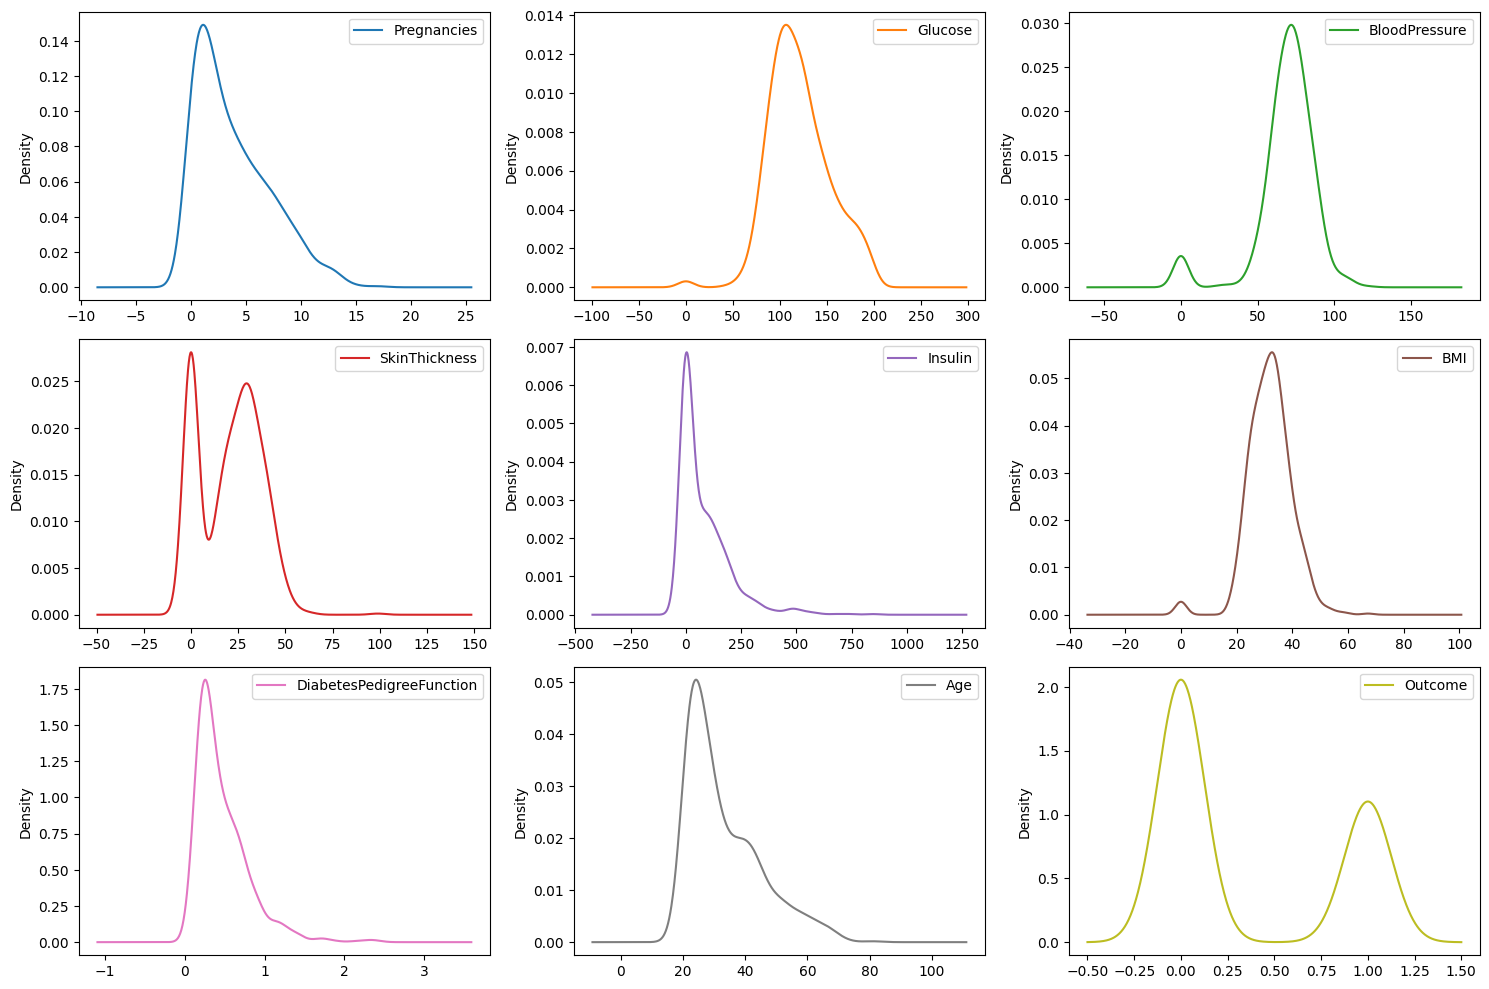

In [6]:
df.select_dtypes(include=['number']).plot(
    kind='kde',
    subplots=True,
    layout=(-1, 3),  # Automatically determines rows, locks columns to 3
    figsize=(15, 10),
    sharex=False     # Allows individual columns to use their own x-axis scale
)

plt.tight_layout()

In [8]:
import numpy as np

columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X = df.drop(['Outcome'],axis=1)
y = df['Outcome']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [18]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [19]:
imputer_transformer = ColumnTransformer(
    transformers=[
        ('age',SimpleImputer(missing_values=np.nan , strategy='median'),['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'])
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)
imputer_transformer.set_output(transform='pandas')

imputer_transformer.fit(X_train)

X_train = imputer_transformer.transform(X_train)
X_test = imputer_transformer.transform(X_test)

In [20]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 353 to 107
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   614 non-null    float64
 1   BloodPressure             614 non-null    float64
 2   SkinThickness             614 non-null    float64
 3   Insulin                   614 non-null    float64
 4   BMI                       614 non-null    float64
 5   Pregnancies               614 non-null    float64
 6   DiabetesPedigreeFunction  614 non-null    float64
 7   Age                       614 non-null    float64
dtypes: float64(8)
memory usage: 43.2 KB


In [23]:
numerical_cols_for_outliers_split = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for col in numerical_cols_for_outliers_split:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower_bound, upper_bound)
    X_test[col] = X_test[col].clip(lower_bound, upper_bound)

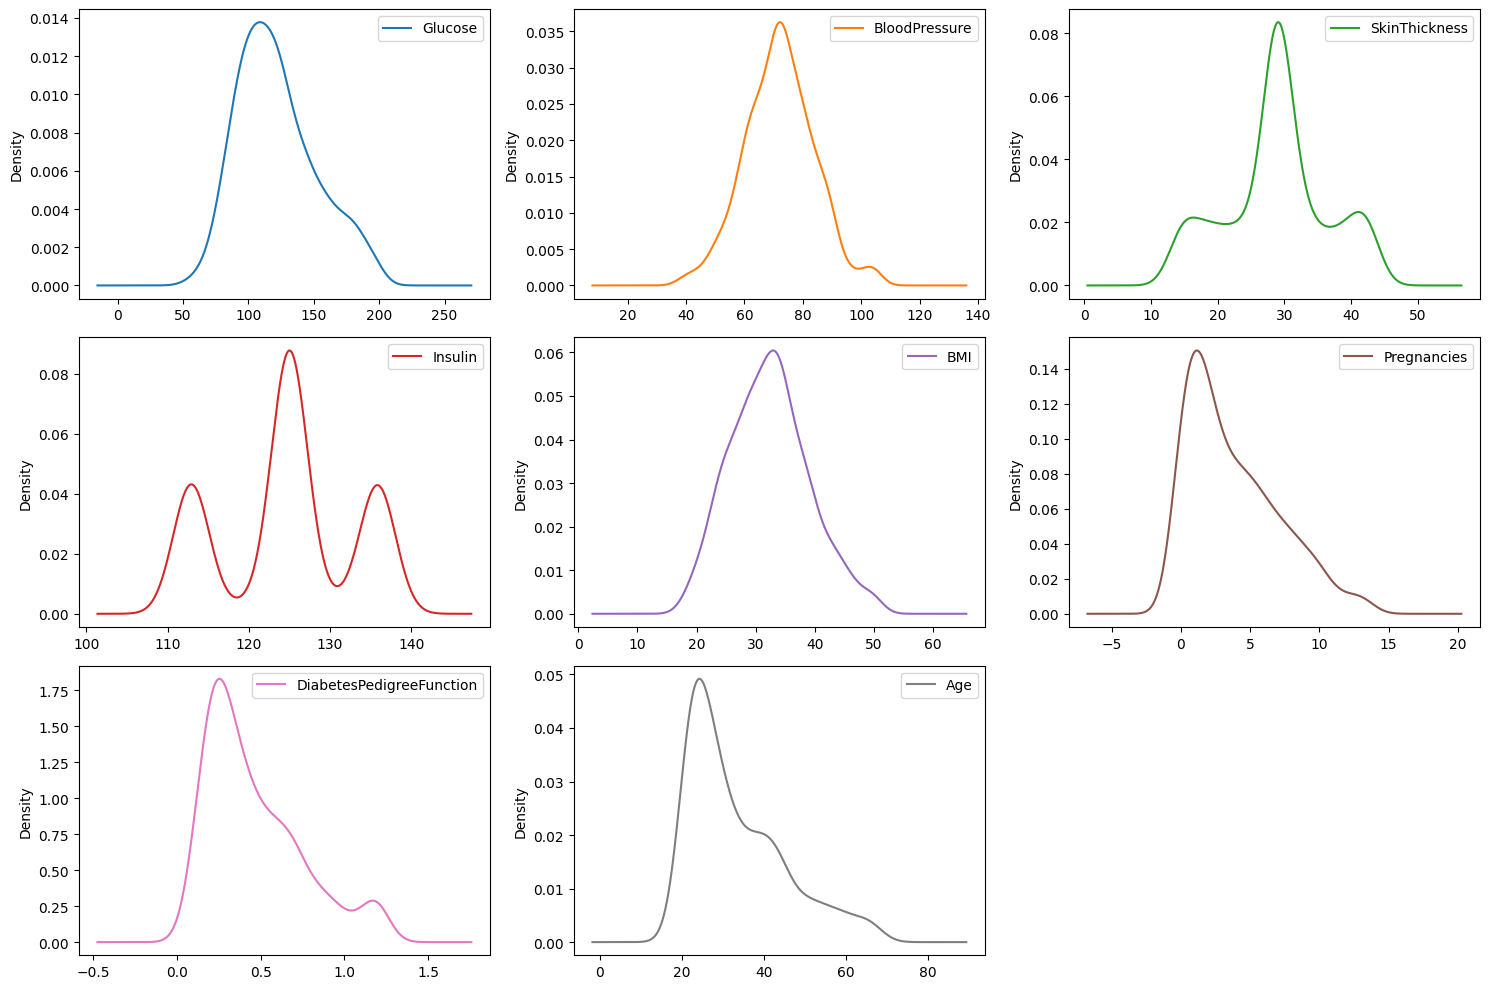

In [24]:
X_train.select_dtypes(include=['number']).plot(
    kind='kde',
    subplots=True,
    layout=(-1, 3),  # Automatically determines rows, locks columns to 3
    figsize=(15, 10),
    sharex=False     # Allows individual columns to use their own x-axis scale
)

plt.tight_layout()

In [27]:
# encoder_scaler = ColumnTransformer(
#     transformers=[
#         ('age_scaler',StandardScaler(),['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])
#     ],
#     remainder='passthrough',
#     verbose_feature_names_out = False
# )
# encoder_scaler.set_output(transform='pandas')

# encoder_scaler.fit(X_train)

# X_train = encoder_scaler.transform(X_train)
# X_test = encoder_scaler.transform(X_test)


In [28]:
standard_scaler = Pipeline(
    steps=[
        ('scaler',StandardScaler())
    ]
)

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('standard_scaler',standard_scaler,['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']),
    ],
    remainder='drop'
)
preprocessor

ColumnTransformer(transformers=[('standard_scaler',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Pregnancies', 'Glucose', 'BloodPressure',
                                  'SkinThickness', 'Insulin', 'BMI',
                                  'DiabetesPedigreeFunction', 'Age'])])

In [31]:
depths = range(1, 21)
train_accuracy = []
test_accuracy = []

In [32]:
from sklearn.tree import DecisionTreeClassifier

In [33]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [34]:
for dep in depths:
  model_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=dep, random_state = 42))])

  model_1.fit(X_train, y_train)
  train_accuracy.append(accuracy_score(y_train, model_1.predict(X_train)))
  test_accuracy.append(accuracy_score(y_test, model_1.predict(X_test)))

In [35]:
print(train_accuracy)
print(test_accuracy)

[0.760586319218241, 0.7638436482084691, 0.7654723127035831, 0.7899022801302932, 0.8143322475570033, 0.8534201954397395, 0.8827361563517915, 0.9201954397394136, 0.9446254071661238, 0.9641693811074918, 0.9804560260586319, 0.990228013029316, 0.998371335504886, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.6948051948051948, 0.6948051948051948, 0.6948051948051948, 0.7922077922077922, 0.7662337662337663, 0.7402597402597403, 0.7467532467532467, 0.7142857142857143, 0.7012987012987013, 0.6818181818181818, 0.7142857142857143, 0.7012987012987013, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753, 0.6753246753246753]


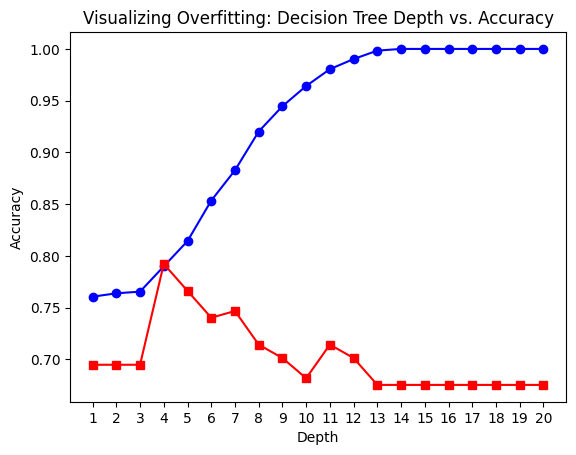

In [37]:
plt.plot(depths, train_accuracy, label = 'Train accuracy', marker = 'o', color = 'blue')

plt.plot(depths, test_accuracy, label = 'Test accuracy', marker = 's', color = 'red')

plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.title("Visualizing Overfitting: Decision Tree Depth vs. Accuracy")
plt.xticks(depths)
plt.show()

Overfitting start at depth 5